In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from sklearn.model_selection import train_test_split
from PIL import Image
import os
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt  # Ajout pour les graphiques


In [3]:
def rotateImage(image, angle):
    image_center = tuple(np.array(image.shape[1::-1]) / 2)
    rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
    return cv2.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv2.INTER_LINEAR)

def bruit(image):
    return np.clip(image + np.random.randn(*image.shape) * random.randint(5, 30), 0, 255).astype(np.uint8)

def change_gamma(image, alpha=1.0, beta=0.0):
    return np.clip(alpha * image + beta, 0, 255).astype(np.uint8)

def color(image, alpha=20):
    return np.clip(image + np.random.randint(-alpha, alpha, size=image.shape, dtype=np.int32), 0, 255).astype(np.uint8)

def random_change(image):
    img = image.copy()
    if np.random.randint(2):
        img = change_gamma(img, random.uniform(0.8, 1.2), np.random.randint(-50, 50))
    if np.random.randint(2):
        img = bruit(img)
    if np.random.randint(2):
        img = color(img)
    return img

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + 1) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1)

def attention_block(x, gating, inter_channels):
    theta_x = layers.Conv2D(inter_channels, (1, 1), strides=(1, 1), padding='same')(x)
    phi_g = layers.Conv2D(inter_channels, (1, 1), strides=(1, 1), padding='same')(gating)

    concat = layers.Add()([theta_x, phi_g])
    concat = layers.Activation('relu')(concat)

    psi = layers.Conv2D(1, (1, 1), strides=(1, 1), padding='same', activation='sigmoid')(concat)
    return layers.Multiply()([x, psi])

In [4]:
def model_attention(nbr):
    entree = layers.Input(shape=(576, 560, 3), dtype='float32')

    result = layers.Conv2D(nbr, 3, activation='relu', padding='same')(entree)
    result = layers.BatchNormalization()(result)
    result = layers.Conv2D(nbr, 3, activation='relu', padding='same')(result)
    result1 = layers.BatchNormalization()(result)

    result = layers.MaxPool2D()(result1)

    result = layers.Conv2D(2 * nbr, 3, activation='relu', padding='same')(result)
    result = layers.BatchNormalization()(result)
    result = layers.Conv2D(2 * nbr, 3, activation='relu', padding='same')(result)
    result2 = layers.BatchNormalization()(result)

    result = layers.MaxPool2D()(result2)

    result = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(result)
    result = layers.BatchNormalization()(result)
    result = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(result)
    result3 = layers.BatchNormalization()(result)

    result = layers.MaxPool2D()(result3)

    result = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(result)
    result = layers.BatchNormalization()(result)
    result = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(result)
    result4 = layers.BatchNormalization()(result)

    result = layers.MaxPool2D()(result4)

    result = layers.Conv2D(8 * nbr, 3, activation='relu', padding='same')(result)
    result = layers.BatchNormalization()(result)
    result = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(result)
    result = layers.BatchNormalization()(result)

    result = layers.UpSampling2D()(result)
    result4 = attention_block(result4, result, 4 * nbr)
    result = layers.Concatenate(axis=3)([result, result4])

    result = layers.UpSampling2D()(result)
    result3 = attention_block(result3, result, 2 * nbr)
    result = layers.Concatenate(axis=3)([result, result3])

    result = layers.UpSampling2D()(result)
    result2 = attention_block(result2, result, nbr)
    result = layers.Concatenate(axis=3)([result, result2])

    result = layers.UpSampling2D()(result)
    result1 = attention_block(result1, result, nbr)
    result = layers.Concatenate(axis=3)([result, result1])

    sortie = layers.Conv2D(1, 1, activation='sigmoid', padding='same')(result)

    return models.Model(inputs=entree, outputs=sortie)

In [5]:
dir_images = '/content/drive/MyDrive/DRIVE/training/images/'
dir_mask  = '/content/drive/MyDrive/DRIVE/training/1st_manual/'

tab_images, tab_masks = [], []
for fichier in os.listdir(dir_images):
    img_orig = cv2.imread(os.path.join(dir_images, fichier))[:576, :560]
    num = fichier.split('_')[0]
    file_mask = os.path.join(dir_mask, num + '_manual1.gif')
    img_mask_orig = np.array(Image.open(file_mask))[:576, :560]

    tab_images.append(img_orig)
    tab_masks.append(img_mask_orig)

tab_images = np.array(tab_images, dtype=np.float32) / 255
tab_masks = np.array(tab_masks, dtype=np.float32) / 255

train_images, test_images, train_masks, test_masks = train_test_split(tab_images, tab_masks, test_size=0.05)
del tab_images, tab_masks

In [6]:
my_model = model_attention(64)
my_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', dice_coef])

In [7]:
history = my_model.fit(train_images, train_masks, epochs=159, batch_size=1, validation_data=(test_images, test_masks))

Epoch 1/159
19/19 ━━━━━━━━━━━━━━━━━━━━ 56s 564ms/step - accuracy: 0.7375 - dice_coef: 0.1771 - loss: 0.8069 - val_accuracy: 0.4783 - val_dice_coef: 0.2410 - val_loss: 1.1676
Epoch 2/159
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 217ms/step - accuracy: 0.9228 - dice_coef: 0.2999 - loss: 0.2055 - val_accuracy: 0.9052 - val_dice_coef: 0.1432 - val_loss: 0.3214
Epoch 3/159
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.9447 - dice_coef: 0.4877 - loss: 0.1544 - val_accuracy: 0.9076 - val_dice_coef: 9.4448e-04 - val_loss: 0.7343
Epoch 4/159
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.9519 - dice_coef: 0.5639 - loss: 0.1344 - val_accuracy: 0.9076 - val_dice_coef: 0.0073 - val_loss: 0.5228
Epoch 5/159
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.9503 - dice_coef: 0.5883 - loss: 0.1381 - val_accuracy: 0.9076 - val_dice_coef: 0.0095 - val_loss: 0.4986
Epoch 6/159
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 221ms/step - accuracy: 0.9545 - dice_coef: 0.6145 - loss: 0.1244 - val_accuracy: 0.9076 

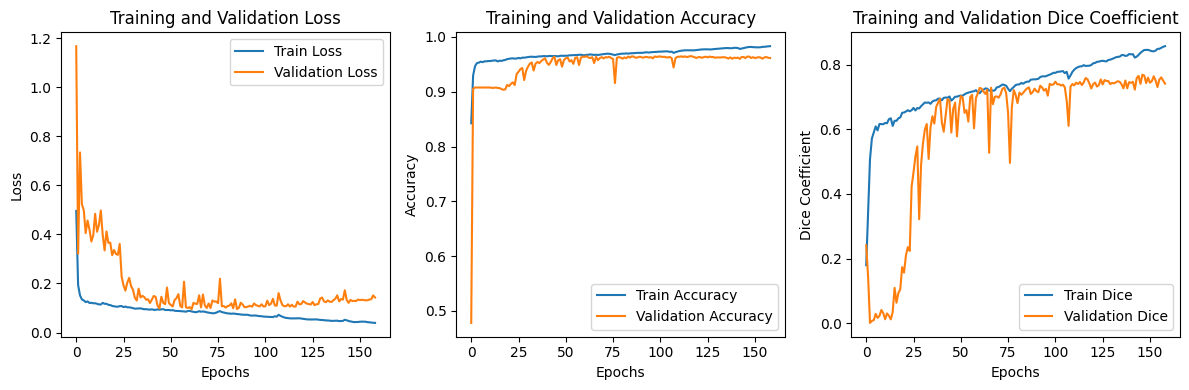

In [10]:
# Affichage des graphiques
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Dice Coefficient
plt.subplot(1, 3, 3)
plt.plot(history.history['dice_coef'], label='Train Dice')
plt.plot(history.history['val_dice_coef'], label='Validation Dice')
plt.title('Training and Validation Dice Coefficient')
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.legend()

plt.tight_layout()
plt.show()



In [12]:
# Enregistrer le modèle dans Google Drive avec un nom spécifique
model_save_path = '/content/drive/MyDrive/UNET+ATTENTION-MODEL.h5'
my_model.save(model_save_path)
print(f"Modèle enregistré sous : {model_save_path}")

Modèle enregistré sous : /content/drive/MyDrive/UNET+ATTENTION-MODEL.h5
